# Integrated Illness Prediction - Electronic Medical Certificate (IIP-EMC) Engine
## Part 2: Leakage-Safe Supervised Learning and Inference Contract

### Objective
- **What is implemented:** a reproducible symptom-classification workflow and a reusable inference contract for the IIP-EMC prototype.
- **How it is implemented:** the notebook consumes fixed preprocessing partitions, evaluates candidate models, tunes one selected architecture, calibrates scores, and saves the chosen model.
- **Why it is implemented this way:** feature selection, balancing, tuning, and calibration are learned from training data only, keeping the final test set independent.
- **Clinical boundary:** the model is a clinician-review cue, not a diagnosis authority.

### Evaluation Policy
- **What is implemented:** a separation between development evaluation and final evaluation.
- **How it is implemented:** cross-validation is applied only to the training partition; the preprocessing notebook's hold-out test set is evaluated once after model selection.
- **Why sampling is inside `imblearn` pipelines:** validation folds never influence the data used to fit feature selection or over-sampling.
- **Why macro recall is primary:** every illness class contributes equally, rather than allowing frequent classes to dominate performance.
- **Why other metrics are reported:** macro F1 and balanced accuracy provide complementary evidence about precision/recall trade-offs and class-balanced performance.
- **Why calibrated scores remain constrained:** probability estimates are operational confidence cues and the web app still requires clinician review.

### Step 1: Load and Validate the Preprocessing Contract
- **What is implemented:** loading of `iip_emc_preprocessed_data.pkl` and validation of its expected keys, schema, binary values, and cross-validation recommendation.
- **How it is implemented:** saved train/test partitions are copied, feature order is checked against metadata, and class support is validated before constructing `StratifiedKFold`.
- **Why it is implemented this way:** model training must use the same ordered feature schema created during preprocessing; early validation prevents silent schema drift.

### Implementation Overview
- **What is implemented:** model benchmarking, tuning, calibration, final evaluation, explainability, and inference-payload generation.
- **How it is implemented:** every development-stage estimator is built as a leakage-safe pipeline; only the selected calibrated model is evaluated against the reserved test set.
- **Why it is implemented this way:** the workflow separates architecture selection from final evaluation and creates traceable artifacts for both the web app and GenAI notebook.
- **Produced artifacts:** `iip_emc_production_model.pkl` stores the model and schema; `latest_inference_payload.pkl` stores a clinician-review payload for the GenAI workflow.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime, timezone
from functools import partial
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.svm import SVC

PREPROCESS_PATH = Path("iip_emc_preprocessed_data.pkl")
PRODUCTION_MODEL_PATH = Path("iip_emc_production_model.pkl")
LATEST_PAYLOAD_PATH = Path("latest_inference_payload.pkl")
MODEL_VERSION = "v4.0-leakage-safe"
RANDOM_STATE = 42

if not PREPROCESS_PATH.exists():
    raise FileNotFoundError("Run Data Preprocessing.ipynb before this notebook.")

data_payload = joblib.load(PREPROCESS_PATH)
required_keys = {
    "x_train", "x_test", "y_train", "y_test", "scaler",
    "feature_columns", "preprocessing_audit",
}
missing_keys = required_keys.difference(data_payload)
if missing_keys:
    raise KeyError(f"Preprocessing artifact is missing required keys: {sorted(missing_keys)}")

x_train = data_payload["x_train"].copy()
x_test = data_payload["x_test"].copy()
y_train = data_payload["y_train"].copy()
y_test = data_payload["y_test"].copy()
feature_columns = list(data_payload["feature_columns"])
preprocessing_audit = data_payload["preprocessing_audit"]

if list(x_train.columns) != feature_columns or list(x_test.columns) != feature_columns:
    raise ValueError("Feature order differs from the preprocessing contract.")
if data_payload["scaler"] is not None:
    raise ValueError("This v4 notebook expects binary symptom flags and no scaler.")
if not x_train.isin([0, 1]).all().all() or not x_test.isin([0, 1]).all().all():
    raise ValueError("Expected only binary 0/1 symptom features.")

cv_folds = int(preprocessing_audit["recommended_cv_folds"])
minimum_train_support = int(y_train.value_counts().min())
if cv_folds < 2 or cv_folds > minimum_train_support:
    raise ValueError("Preprocessing CV recommendation is incompatible with class support.")

cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
print(f"Model version: {MODEL_VERSION}")
print(f"Training rows: {len(x_train)} | Test rows: {len(x_test)} | Features: {len(feature_columns)}")
print(f"Classes: {y_train.nunique()} | Minimum training support: {minimum_train_support}")
print(f"Cross-validation folds: {cv_folds}")
print("Clinical safety policy: every model result requires clinician review.")

Model version: v4.0-leakage-safe
Training rows: 244 | Test rows: 61 | Features: 132
Classes: 41 | Minimum training support: 4
Cross-validation folds: 3
Clinical safety policy: every model result requires clinician review.


### Step 2: Define Leakage-Safe Pipelines
- **What is implemented:** feature selection, class balancing, and three candidate classifiers in one `imblearn` pipeline.
- **How it is implemented:** `SelectKBest` with mutual information and `RandomOverSampler` are fitted within each training fold before Logistic Regression, Random Forest, or SVM fitting.
- **Why `RandomOverSampler` is used:** it preserves valid binary symptom flags, unlike ordinary SMOTE which can create fractional symptom values.
- **Why `PARALLEL_JOBS = 1` is used:** serial execution avoids Windows/Jupyter process-worker failures while preserving the evaluation methodology.

In [2]:
mi_score = partial(mutual_info_classif, discrete_features=True, random_state=RANDOM_STATE)

# Keep notebook execution reliable across Windows and Jupyter kernels.
# Set this to -1 only after confirming that process-based parallelism works.
PARALLEL_JOBS = 1

def make_pipeline(classifier, k=40):
    return Pipeline(steps=[
        ("feature_selection", SelectKBest(score_func=mi_score, k=k)),
        ("balancing", RandomOverSampler(random_state=RANDOM_STATE)),
        ("classifier", classifier),
    ])

base_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000, solver="liblinear", multi_class="ovr", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=PARALLEL_JOBS
    ),
    "Support Vector Machine": SVC(
        probability=True, class_weight="balanced", random_state=RANDOM_STATE
    ),
}

scoring = {
    "macro_recall": "recall_macro",
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
}

print("Pipelines prepared. No model has seen the hold-out test set.")

Pipelines prepared. No model has seen the hold-out test set.


### Step 3: Cross-Validated Baseline Benchmark
- **What is implemented:** cross-validated comparison of the candidate pipelines.
- **How it is implemented:** each model is evaluated using the same stratified folds and macro recall, macro F1, and balanced-accuracy scorers.
- **Why it is implemented this way:** architecture selection is based only on training data; the hold-out test set remains untouched for final evaluation.

In [3]:
baseline_records = []

for model_name, classifier in base_models.items():
    pipeline = make_pipeline(clone(classifier), k=40)
    scores = cross_validate(
        pipeline, x_train, y_train, cv=cv, scoring=scoring, n_jobs=PARALLEL_JOBS, return_train_score=False
    )
    baseline_records.append({
        "model": model_name,
        "cv_macro_recall_mean": scores["test_macro_recall"].mean(),
        "cv_macro_recall_std": scores["test_macro_recall"].std(),
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
    })

baseline_results = pd.DataFrame(baseline_records).sort_values(
    "cv_macro_recall_mean", ascending=False
).reset_index(drop=True)

baseline_display = baseline_results.copy()
for column in baseline_display.columns[1:]:
    baseline_display[column] = (baseline_display[column] * 100).round(2)

baseline_display

,model,cv_macro_recall_mean,cv_macro_recall_std,cv_macro_f1_mean,cv_balanced_accuracy_mean
0,Logistic Regression,87.94,0.84,85.84,87.94
1,Random Forest,85.09,1.26,82.94,85.09
2,Support Vector Machine,85.09,0.69,82.71,85.09


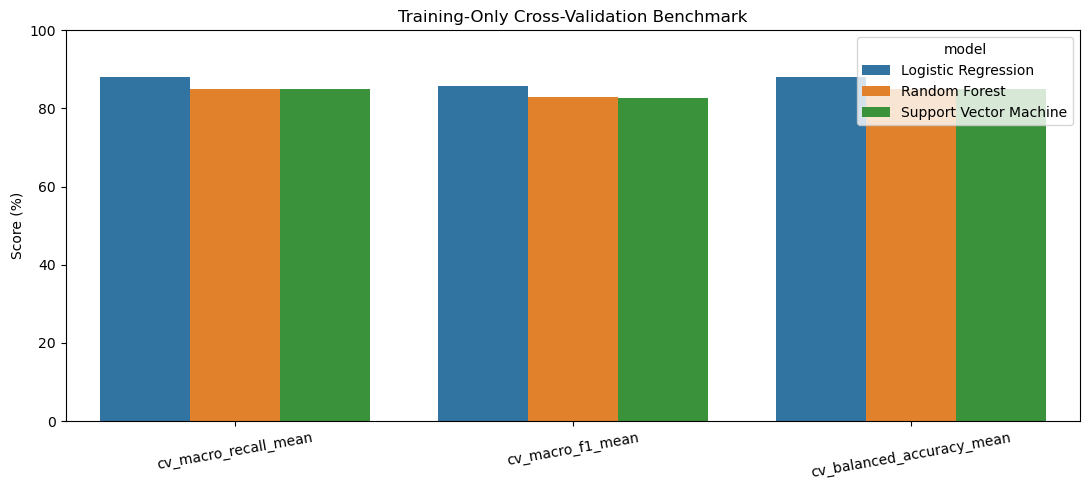

In [4]:
plot_data = baseline_results.melt(
    id_vars="model",
    value_vars=["cv_macro_recall_mean", "cv_macro_f1_mean", "cv_balanced_accuracy_mean"],
    var_name="metric",
    value_name="score",
)
plot_data["score"] *= 100

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_data, x="metric", y="score", hue="model")
plt.title("Training-Only Cross-Validation Benchmark")
plt.xlabel("")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Step 4: Tune the Best Development Architecture
- **What is implemented:** hyperparameter search for the baseline architecture with the highest mean cross-validated macro recall.
- **How it is implemented:** `GridSearchCV` searches the selected pipeline while retaining the same stratified training-only folds and scoring metric.
- **Why it is implemented this way:** tuning only the winning baseline controls project complexity and protects the hold-out test set from repeated development decisions.

In [5]:
winning_model_name = baseline_results.iloc[0]["model"]
winning_classifier = clone(base_models[winning_model_name])

parameter_grids = {
    "Logistic Regression": {
        "feature_selection__k": [20, 40, "all"],
        "classifier__C": [0.1, 1.0, 10.0],
    },
    "Random Forest": {
        "feature_selection__k": [20, 40, "all"],
        "classifier__n_estimators": [200, 350],
        "classifier__max_depth": [None, 12],
        "classifier__min_samples_leaf": [1, 2],
    },
    "Support Vector Machine": {
        "feature_selection__k": [20, 40, "all"],
        "classifier__C": [0.5, 1.0, 5.0],
        "classifier__kernel": ["linear", "rbf"],
    },
}

grid_search = GridSearchCV(
    estimator=make_pipeline(winning_classifier, k=40),
    param_grid=parameter_grids[winning_model_name],
    scoring="recall_macro",
    cv=cv,
    n_jobs=PARALLEL_JOBS,
    refit=True,
)
grid_search.fit(x_train, y_train)
optimized_pipeline = grid_search.best_estimator_

print(f"Selected development architecture: {winning_model_name}")
print(f"Best training CV macro recall: {grid_search.best_score_ * 100:.2f}%")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Selected symptom count: {optimized_pipeline.named_steps['feature_selection'].get_support().sum()}")

Selected development architecture: Logistic Regression
Best training CV macro recall: 100.00%
Best parameters: {'classifier__C': 1.0, 'feature_selection__k': 'all'}
Selected symptom count: 132


### Step 5: Calibrate Model Scores
- **What is implemented:** probability calibration for the selected model.
- **How it is implemented:** `CalibratedClassifierCV` refits calibrated probability estimates using training data and the selected pipeline.
- **Why it is implemented this way:** displayed score values are more interpretable operational cues, while remaining explicitly separate from clinical certainty or diagnosis probability.

In [6]:
calibrated_model = CalibratedClassifierCV(
    estimator=clone(optimized_pipeline),
    method="sigmoid",
    cv=cv,
)
calibrated_model.fit(x_train, y_train)

print("Sigmoid calibration fitted using training data only.")
print(f"Calibrated classes: {len(calibrated_model.classes_)}")

Sigmoid calibration fitted using training data only.
Calibrated classes: 41


### Step 6: Final Evaluation on the Untouched Hold-Out Test Set
- **What is implemented:** final predictions, aggregate metrics, classification report, and confusion matrix on the reserved test partition.
- **How it is implemented:** the tuned calibrated model is fitted from training data and evaluated once against `x_test` and `y_test`.
- **Why it is implemented this way:** one final evaluation gives a less biased estimate than reusing test data during model selection.
- **Limitation:** small per-class support makes individual-class estimates unstable and prevents claims of clinical validation.

In [7]:
test_predictions = calibrated_model.predict(x_test)
test_probabilities = calibrated_model.predict_proba(x_test)

test_accuracy = accuracy_score(y_test, test_predictions)
test_macro_precision = precision_score(y_test, test_predictions, average="macro", zero_division=0)
test_macro_recall = recall_score(y_test, test_predictions, average="macro", zero_division=0)
test_macro_f1 = f1_score(y_test, test_predictions, average="macro", zero_division=0)
test_balanced_accuracy = balanced_accuracy_score(y_test, test_predictions)

# Multiclass Brier score: lower is better. It evaluates probability quality, not clinical validity.
class_to_index = {label: index for index, label in enumerate(calibrated_model.classes_)}
one_hot_test = np.zeros_like(test_probabilities)
one_hot_test[np.arange(len(y_test)), [class_to_index[label] for label in y_test]] = 1
multiclass_brier_score = float(np.mean(np.sum((test_probabilities - one_hot_test) ** 2, axis=1)))

final_metrics = pd.DataFrame([{
    "accuracy": test_accuracy,
    "macro_precision": test_macro_precision,
    "macro_recall": test_macro_recall,
    "macro_f1": test_macro_f1,
    "balanced_accuracy": test_balanced_accuracy,
    "multiclass_brier_score_lower_is_better": multiclass_brier_score,
}])

final_metrics.style.format({column: "{:.2%}" for column in final_metrics.columns if column != "multiclass_brier_score_lower_is_better"}).format({"multiclass_brier_score_lower_is_better": "{:.4f}"})

,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy,multiclass_brier_score_lower_is_better
0,1.000000,1.000000,1.000000,1.000000,1.000000,0.2105


Full hold-out classification report:
                                        precision    recall  f1-score   support

(vertigo) Paroymsal Positional Vertigo       1.00      1.00      1.00         1
                                  AIDS       1.00      1.00      1.00         1
                                  Acne       1.00      1.00      1.00         1
                   Alcoholic hepatitis       1.00      1.00      1.00         2
                               Allergy       1.00      1.00      1.00         1
                             Arthritis       1.00      1.00      1.00         1
                      Bronchial Asthma       1.00      1.00      1.00         1
                  Cervical spondylosis       1.00      1.00      1.00         1
                           Chicken pox       1.00      1.00      1.00         2
                   Chronic cholestasis       1.00      1.00      1.00         2
                           Common Cold       1.00      1.00      1.00         2
  

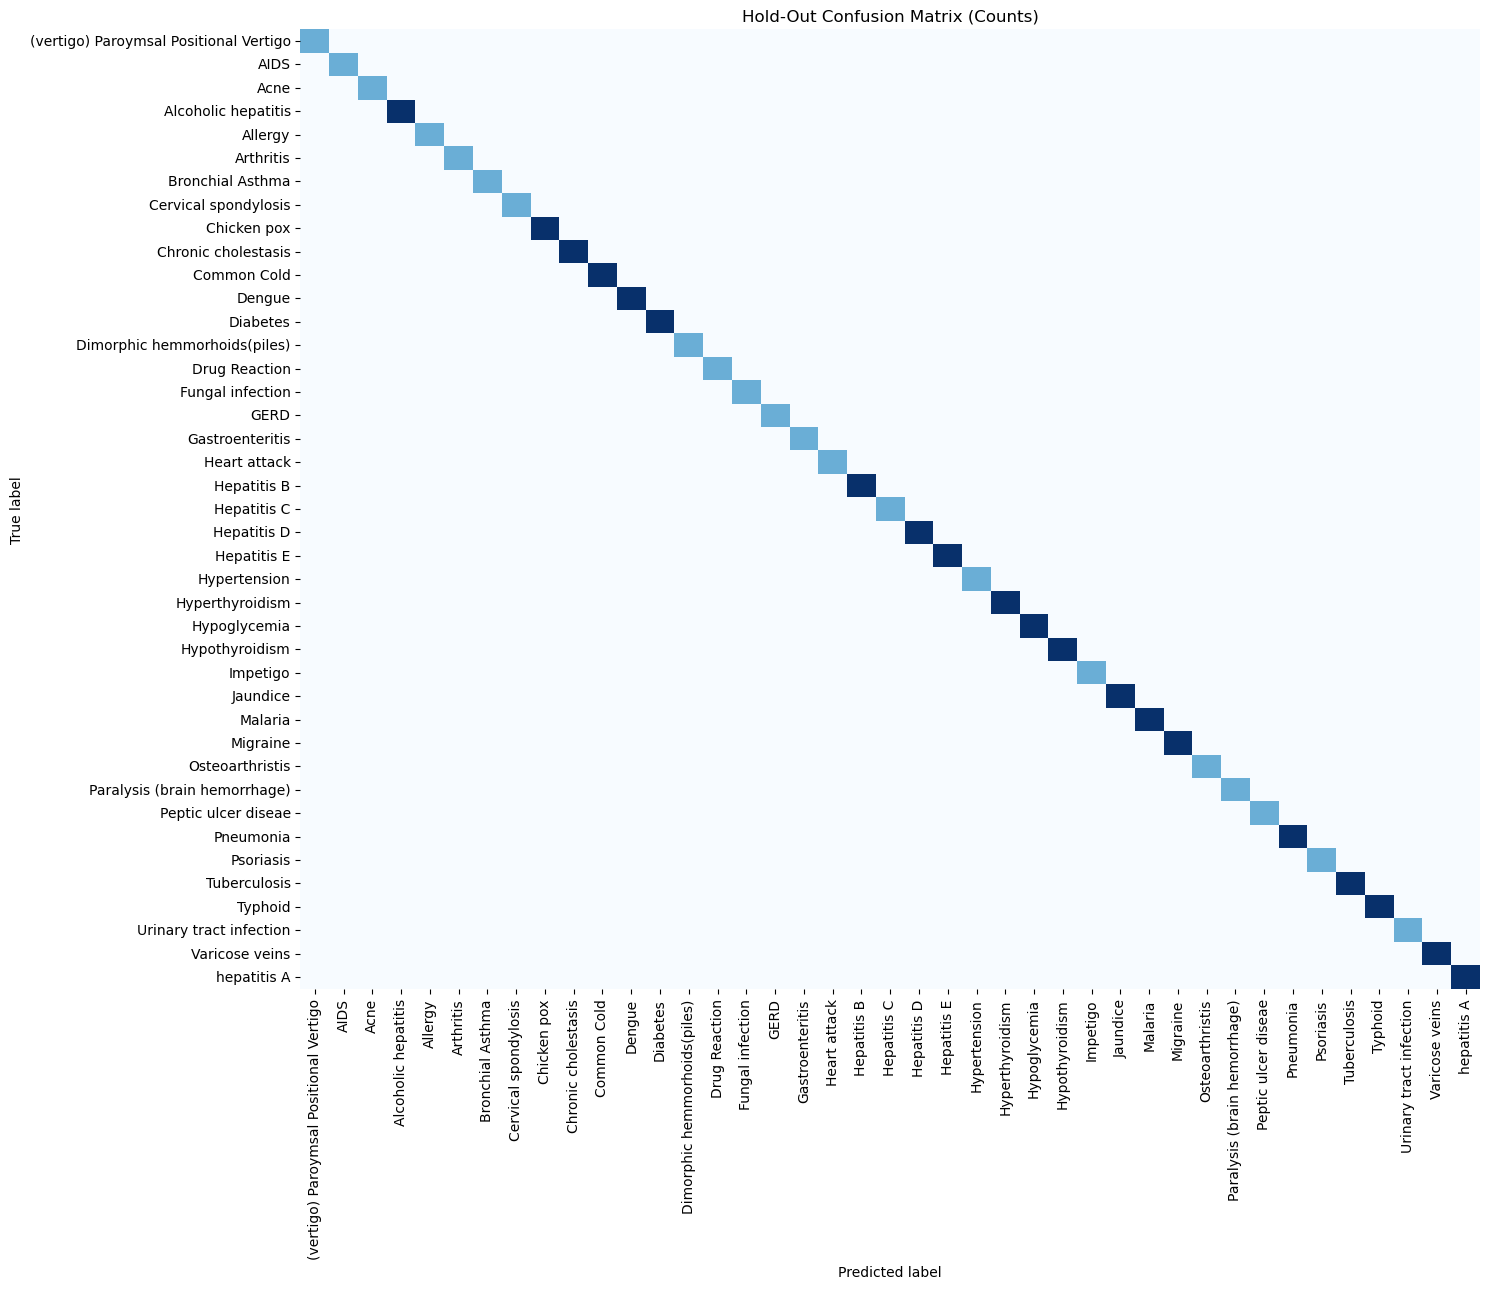

Smallest hold-out class support: 1
Interpret per-class metrics cautiously when a class has only one or two examples.


In [8]:
print("Full hold-out classification report:")
print(classification_report(y_test, test_predictions, zero_division=0))

labels = list(calibrated_model.classes_)
cm = confusion_matrix(y_test, test_predictions, labels=labels)

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(cm, cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
ax.set_title("Hold-Out Confusion Matrix (Counts)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

test_support = y_test.value_counts().sort_values()
print("Smallest hold-out class support:", int(test_support.min()))
print("Interpret per-class metrics cautiously when a class has only one or two examples.")

### Step 7: Explainability for Clinician Review
- **What is implemented:** permutation-importance ranking of symptom inputs.
- **How it is implemented:** each test-set feature is shuffled repeatedly and the resulting change in macro recall is measured.
- **Why it is implemented this way:** the chart provides transparent model-behaviour evidence without claiming that a symptom causes a disease.

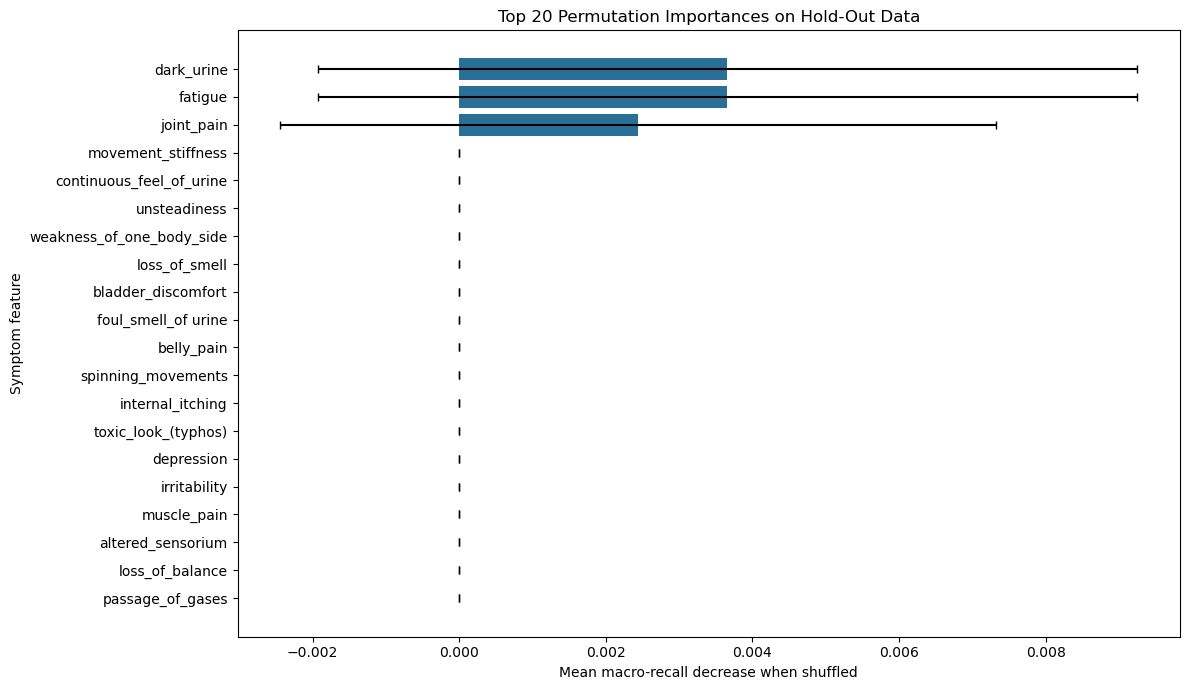

,feature,importance_mean,importance_std
33,dark_urine,0.003659,0.005589
14,fatigue,0.003659,0.005589
6,joint_pain,0.002439,0.004878
91,continuous_feel_of_urine,0.000000,0.000000
86,unsteadiness,0.000000,0.000000
87,weakness_of_one_body_side,0.000000,0.000000
88,loss_of_smell,0.000000,0.000000
89,bladder_discomfort,0.000000,0.000000
90,foul_smell_of urine,0.000000,0.000000
92,passage_of_gases,0.000000,0.000000


In [9]:
importance_result = permutation_importance(
    calibrated_model,
    x_test,
    y_test,
    scoring="recall_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=PARALLEL_JOBS,
)

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": importance_result.importances_mean,
    "importance_std": importance_result.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(12, 7))
top_importance = feature_importance.head(20).sort_values("importance_mean")
plt.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
    color="#2a6f97",
    capsize=3,
)
plt.title("Top 20 Permutation Importances on Hold-Out Data")
plt.xlabel("Mean macro-recall decrease when shuffled")
plt.ylabel("Symptom feature")
plt.tight_layout()
plt.show()

feature_importance.head(20)

### Step 8: Reusable Inference Contract
- **What is implemented:** schema-validated inference functions that create a complete binary symptom dictionary and structured prediction payload.
- **How it is implemented:** the function checks the saved feature order, transforms active symptoms into `0/1` values, and returns the top prediction, confidence, alternatives, and manual-review status.
- **Why it is implemented this way:** both the Flask app and GenAI notebook receive consistent, validated inputs and every prediction remains marked for clinician review.

In [10]:
def generate_diagnostic_payload(raw_symptom_input: dict, patient_admin_metadata: dict, model, feature_columns: list) -> dict:
    """Validate one symptom record and return a clinician-review payload.

    This function is for educational triage support only. It does not diagnose,
    choose leave duration, or authorise certificate issuance.
    """
    missing_features = [feature for feature in feature_columns if feature not in raw_symptom_input]
    extra_features = [feature for feature in raw_symptom_input if feature not in feature_columns]
    if missing_features:
        raise ValueError(f"Missing symptom fields: {missing_features}")
    if extra_features:
        raise ValueError(f"Unexpected symptom fields: {extra_features}")

    patient_features = pd.DataFrame([raw_symptom_input], columns=feature_columns)
    if not patient_features.isin([0, 1]).all().all():
        raise ValueError("Every symptom field must be binary: 0 (absent) or 1 (present).")

    predicted_label = model.predict(patient_features)[0]
    probabilities = model.predict_proba(patient_features)[0]
    ordered_indices = np.argsort(probabilities)[::-1]
    primary_index = int(ordered_indices[0])

    return {
        "primary_predicted_diagnosis": predicted_label,
        "prediction_confidence_percentage": round(float(probabilities[primary_index] * 100), 2),
        "prediction_score_label": "calibrated model score; not clinical certainty",
        "clinical_differential_alternatives": [
            {
                "alternative_condition": model.classes_[index],
                "confidence": round(float(probabilities[index] * 100), 2),
            }
            for index in ordered_indices[1:3]
        ],
        "requires_manual_review": True,
        "patient_admin_metadata": patient_admin_metadata,
        "triage_feature_snapshot": raw_symptom_input,
    }


# A non-interactive demonstration record keeps the notebook reproducible.
demo_features = {feature: int(x_test.iloc[0][feature]) for feature in feature_columns}
demo_metadata = {
    "patient_name": "Demo Patient",
    "patient_id": "DEMO-ONLY",
    "patient_age": 0,
    "clinic_name": "Demo Clinic",
    "clinic_address": "Demo Address",
    "attending_clinician_name": "Dr Demo",
    "clinician_registration_no": "DEMO",
    "consultation_date": "2026-01-01",
    "medical_leave_start_date": "2026-01-01",
    "authorized_medical_leave_days": 1,
    "certificate_recipient": "Demo Recipient",
    "diagnosis_disclosure_consent": False,
    "clinician_review_status": "PENDING_REVIEW",
}

demo_payload = generate_diagnostic_payload(
    demo_features, demo_metadata, calibrated_model, feature_columns
)
print("Inference contract test passed.")
print(f"Demo predicted triage label: {demo_payload['primary_predicted_diagnosis']}")
print(f"Manual review required: {demo_payload['requires_manual_review']}")

Inference contract test passed.
Demo predicted triage label: Migraine
Manual review required: True


### Step 9: Save Versioned Model and Demonstration Payload
- **What is implemented:** serialization of the production model, feature layout, evaluation metadata, safety policy, and a sample inference payload.
- **How it is implemented:** `joblib` writes the model artifact and the latest prediction payload using explicit version metadata.
- **Why it is implemented this way:** the web app can dynamically render the exact symptom schema and the GenAI workflow receives structured, clinician-only context rather than unvalidated free text.

In [11]:
model_metadata = {
    "model_version": MODEL_VERSION,
    "trained_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "preprocessing_version": preprocessing_audit["preprocessing_version"],
    "model_name": winning_model_name,
    "feature_count": len(feature_columns),
    "selected_feature_count": int(optimized_pipeline.named_steps["feature_selection"].get_support().sum()),
    "cv_folds": cv_folds,
    "development_cv_macro_recall": float(grid_search.best_score_),
    "holdout_metrics": final_metrics.iloc[0].to_dict(),
    "review_policy": "All predictions require clinician review; model scores cannot issue an EMC.",
    "known_limitations": preprocessing_audit["known_limitations"],
}

production_model_payload = {
    "model": calibrated_model,
    "features_layout": feature_columns,
    "scaler": None,
    "label_classes": list(calibrated_model.classes_),
    "model_metadata": model_metadata,
}

joblib.dump(production_model_payload, PRODUCTION_MODEL_PATH)
joblib.dump(demo_payload, LATEST_PAYLOAD_PATH)

print(f"Saved model artifact: {PRODUCTION_MODEL_PATH.resolve()}")
print(f"Saved demo GenAI payload: {LATEST_PAYLOAD_PATH.resolve()}")
print("Do not use the demo payload as a patient record.")

Saved model artifact: C:\Users\jys20\miniconda3\envs\it3100\AAP\iip_emc_production_model.pkl
Saved demo GenAI payload: C:\Users\jys20\miniconda3\envs\it3100\AAP\latest_inference_payload.pkl
Do not use the demo payload as a patient record.


### Summary
- **Implemented:** training-contract validation, leakage-safe pipelines, model benchmarking, selected-model tuning, probability calibration, hold-out evaluation, permutation importance, validated inference, and artifact serialization.
- **Implementation approach:** selectors and balancing operate inside training folds; architecture decisions use cross-validation; the hold-out partition is used only for final evaluation.
- **Why this approach:** it provides traceable performance evidence while reducing leakage and duplicate evaluation bias.
- **Outputs:** `iip_emc_production_model.pkl` supplies the app model/schema; `latest_inference_payload.pkl` supplies structured clinician-review context to GenAI.
- **Limitation and control:** model scores are not clinical diagnoses; downstream GenAI and final EMC issuance remain behind mandatory clinician review and approval.